In [1]:
import xarray as xr

## Load data

In [2]:
optics = xr.open_dataset('/work/bk1450/b383184/Amazon/plume/data/test/optics.nc')
optics

<xarray.Dataset> Size: 9GB
Dimensions:    (time: 1210, latitude: 960, longitude: 960)
Coordinates:
  * latitude   (latitude) float32 4kB -9.979 -9.938 -9.896 ... 29.9 29.94 29.98
  * longitude  (longitude) float32 4kB -74.98 -74.94 -74.9 ... -35.06 -35.02
  * time       (time) datetime64[ns] 10kB 2022-06-01 2022-06-02 ... 2025-09-22
Data variables:
    KD490      (time, latitude, longitude) float32 4GB ...
    ZSD        (time, latitude, longitude) float32 4GB ...
Attributes:
    title:        cmems_obs-oc_glo_bgc-transp_my_l4-gapfree-multi-4km_P1D
    history:      Created using software developed at ACRI-ST
    institution:  ACRI
    Conventions:  CF-1.8, ACDD-1.3
    comment:      average
    references:   http://www.globcolour.info GlobColour has been originally f...
    contact:      servicedesk.cmems@acri-st.fr
    source:       surface observation

In [3]:
sal = xr.open_mfdataset('sal/sal_*', chunks={"depth": 1}).isel(depth=0)
sal

<xarray.Dataset> Size: 7GB
Dimensions:    (time: 1205, latitude: 1201, longitude: 1201)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 10kB 2022-06-01 2022-06-02 ... 2025-09-17
Data variables:
    so         (time, latitude, longitude) float32 7GB dask.array<chunksize=(30, 1201, 1201), meta=np.ndarray>
Attributes:
    credit:                    E.U. Copernicus Marine Service Information (CM...
    references:                http://marine.copernicus.eu
    contact:                   https://marine.copernicus.eu/contact
    institution:               Mercator Ocean International
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MOI GLO12
    Conventions:               CF-1.8
    copernicusmarine_version:  2.2.0

In [4]:
t = xr.open_mfdataset('temp/temp_*',chunks={"depth": 1}).isel(depth=0)
t

<xarray.Dataset> Size: 7GB
Dimensions:    (time: 1205, latitude: 1201, longitude: 1201)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 10kB 2022-06-01 2022-06-02 ... 2025-09-17
Data variables:
    thetao     (time, latitude, longitude) float32 7GB dask.array<chunksize=(30, 1201, 1201), meta=np.ndarray>
Attributes:
    references:                http://marine.copernicus.eu
    contact:                   https://marine.copernicus.eu/contact
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    institution:               Mercator Ocean International
    Conventions:               CF-1.8
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MOI GLO12
    credit:                    E.U. Copernicus Marine Service Information (CM...
    copernicusmarine_version:  2.2.0

In [10]:
ssh = xr.open_mfdataset('ssh/ssh_*.nc')

In [5]:
U = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Atlantic/data/UV/U_*',chunks={"depth": 1}).isel(depth=0)
V = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Atlantic/data/UV/V_*',chunks={"depth": 1}).isel(depth=0)

UV = (U.uo**2 + V.vo**2)**0.5
UV

<xarray.DataArray (time: 1148, latitude: 1201, longitude: 1201)> Size: 7GB
dask.array<pow, shape=(1148, 1201, 1201), dtype=float32, chunksize=(31, 1201, 1201), chunktype=numpy.ndarray>
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 9kB 2022-06-01 2022-06-02 ... 2025-07-22

In [6]:
KE = 0.5 * (U.uo**2 + V.vo**2)

In [7]:
import numpy as np
# grid metrics (meters per degree)
lat = U.latitude
lon = U.longitude
Re = 6_371_000.0
deg2rad = np.pi/180.0
dx = (Re * np.cos(np.deg2rad(lat)) * deg2rad) * xr.ones_like(lon)  # m/deg lon
dy = (Re * deg2rad) * xr.ones_like(lat)                            # m/deg lat

# finite differences (central where possible)
du_dy = U.uo.differentiate('latitude') / dy
dv_dx = V.vo.differentiate('longitude') / dx

vort = dv_dx - du_dy  # s^-1

## 5 day averages

In [14]:
sal5 = sal.resample(time="5D").mean()
# sal5c = sal5.chunk({'time': -1, 'latitude': -1, 'longitude': -1})
# sal5.compute().to_netcdf('sal5.nc')
sal5

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 241, latitude: 1201, longitude: 1201)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 2kB 2022-06-01 2022-06-06 ... 2025-09-13
Data variables:
    so         (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 1201, 1201), meta=np.ndarray>
Attributes:
    credit:                    E.U. Copernicus Marine Service Information (CM...
    references:                http://marine.copernicus.eu
    contact:                   https://marine.copernicus.eu/contact
    institution:               Mercator Ocean International
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MOI GLO12
    Conventions:               CF-1.8
    copernicusmarine_version:  2.2.0

In [24]:
sal5 = sal5.compute()
sal5.to_netcdf('sal5.nc')

In [51]:
ss = sal5.drop_sel(time='2022-06-01')
ss = ss.resample(time="10D").mean()
# ss.to_netcdf('sal10.nc')

### Temperature

In [27]:
t5 = t.resample(time="5D").mean()
t5 = t5.compute()
t5.to_netcdf('t5.nc')

### UV 

In [45]:
UV5 = UV.resample(time="5D").mean()
UV5 = UV5.compute()

In [49]:
UV5

<xarray.DataArray (time: 230, latitude: 1201, longitude: 1201)> Size: 1GB
array([[[0.12292478, 0.09631298, 0.07218745, ..., 0.6376086 ,
         0.6490513 , 0.65820503],
        [0.11452608, 0.08158989, 0.06443864, ..., 0.5071889 ,
         0.50817585, 0.50957245],
        [0.10924862, 0.07354453, 0.06111393, ..., 0.40388018,
         0.39827883, 0.3958816 ],
        ...,
        [       nan,        nan,        nan, ..., 0.061595  ,
         0.06446057, 0.06391279],
        [       nan,        nan,        nan, ..., 0.07515121,
         0.06316613, 0.06678482],
        [       nan,        nan,        nan, ..., 0.06015629,
         0.04555406, 0.05432504]],

       [[0.1198189 , 0.10762304, 0.07406309, ..., 0.3178166 ,
         0.3216524 , 0.32897896],
        [0.12228362, 0.10591403, 0.06990141, ..., 0.26424557,
         0.26987034, 0.27699265],
        [0.1304057 , 0.10446565, 0.06776579, ..., 0.25344685,
         0.26159263, 0.26734334],
...
        [       nan,        nan,        nan, ..., 0.0565966 ,
         0.06161358, 0.08376642],
        [       nan,        nan,        nan, ..., 0.05000951,
         0.04197381, 0.03968465],
        [       nan,        nan,        nan, ..., 0.0420225 ,
         0.03630206, 0.03708683]],

       [[0.04170755, 0.05249345, 0.06764227, ..., 0.31293294,
         0.30922255, 0.323159  ],
        [0.02969517, 0.03210985, 0.03679538, ..., 0.29521608,
         0.31328484, 0.3380448 ],
        [0.03225177, 0.03140409, 0.02759042, ..., 0.31821725,
         0.33872792, 0.35432395],
        ...,
        [       nan,        nan,        nan, ..., 0.03781472,
         0.04448646, 0.04110458],
        [       nan,        nan,        nan, ..., 0.06178216,
         0.05907136, 0.04716092],
        [       nan,        nan,        nan, ..., 0.07506663,
         0.06270441, 0.04623514]]], shape=(230, 1201, 1201), dtype=float32)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 2kB 2022-06-01 2022-06-06 ... 2025-07-20

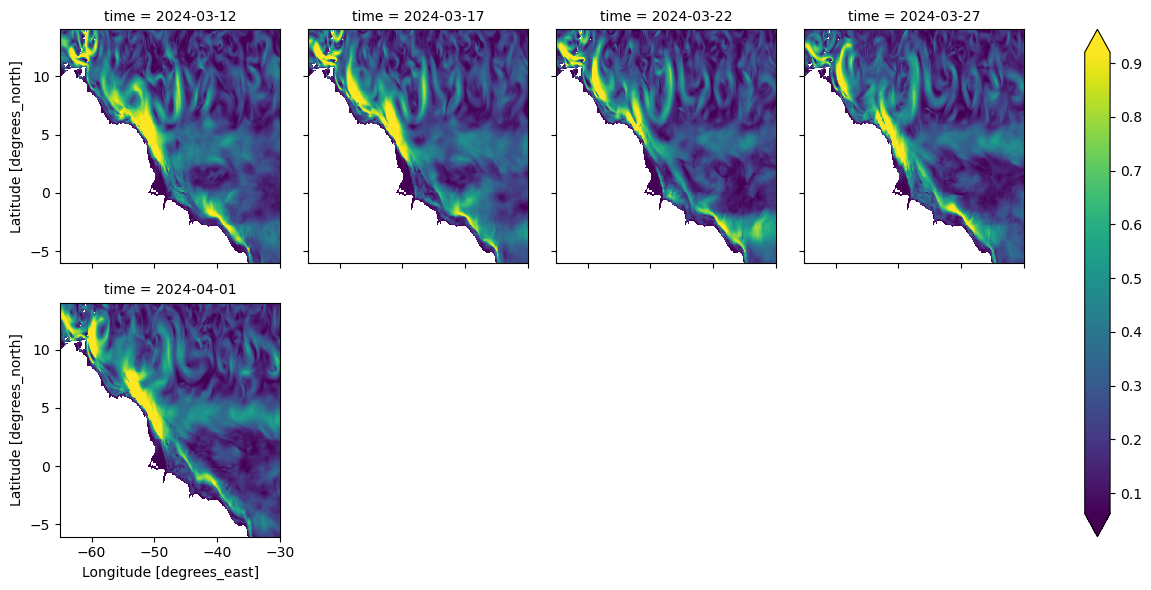

In [50]:
UV5.sel(time=slice('2024-03-10','2024-04-01')).sel(longitude=slice(-65,-30),latitude=slice(-6,14)).plot(col='time',col_wrap=4, robust=True)

#### KE

In [16]:
KE5= KE.resample(time="5D").mean()
KE5 = KE5.compute()
KE5

<xarray.DataArray (time: 230, latitude: 1201, longitude: 1201)> Size: 1GB
array([[[0.00857272, 0.00587076, 0.00356144, ..., 0.21007101,
         0.2180407 , 0.22444096],
        [0.00758384, 0.00439642, 0.00286213, ..., 0.13614704,
         0.13724174, 0.13829392],
        [0.00694553, 0.00359716, 0.00256557, ..., 0.08760166,
         0.08549313, 0.08445383],
        ...,
        [       nan,        nan,        nan, ..., 0.00254534,
         0.00242461, 0.00226982],
        [       nan,        nan,        nan, ..., 0.00326963,
         0.0022243 , 0.00245452],
        [       nan,        nan,        nan, ..., 0.002013  ,
         0.00124447, 0.00164301]],

       [[0.00793283, 0.00652741, 0.00341231, ..., 0.05408119,
         0.0554349 , 0.05798611],
        [0.00822095, 0.00622756, 0.00298905, ..., 0.03686783,
         0.03810652, 0.03983657],
        [0.00912662, 0.00587822, 0.00278833, ..., 0.0335801 ,
         0.03536197, 0.03656525],
...
        [       nan,        nan,        nan, ..., 0.00196852,
         0.00237746, 0.00446456],
        [       nan,        nan,        nan, ..., 0.00172518,
         0.00116111, 0.00112141],
        [       nan,        nan,        nan, ..., 0.00140904,
         0.00095817, 0.00084805]],

       [[0.00111127, 0.00172138, 0.00263313, ..., 0.04903322,
         0.04799133, 0.052526  ],
        [0.00058038, 0.00063472, 0.00096851, ..., 0.04376051,
         0.04932467, 0.05737625],
        [0.00065911, 0.00063944, 0.00054795, ..., 0.05082368,
         0.05753148, 0.06290778],
        ...,
        [       nan,        nan,        nan, ..., 0.00073137,
         0.00101268, 0.00091733],
        [       nan,        nan,        nan, ..., 0.00220792,
         0.0018509 , 0.00113376],
        [       nan,        nan,        nan, ..., 0.00307424,
         0.00213389, 0.00122706]]], shape=(230, 1201, 1201), dtype=float32)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 2kB 2022-06-01 2022-06-06 ... 2025-07-20

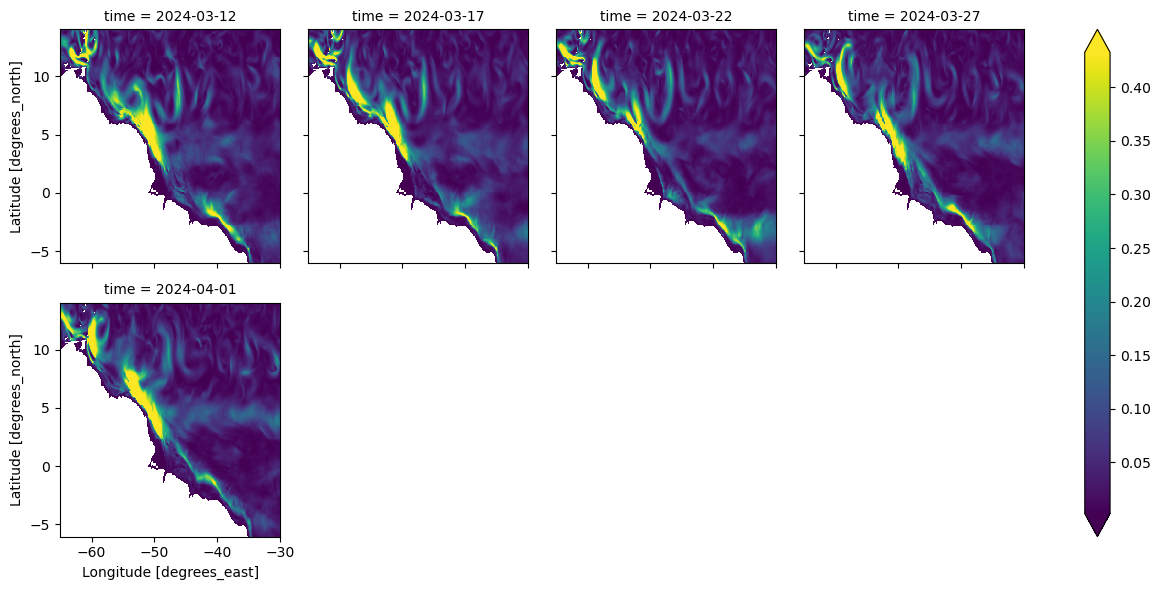

In [55]:
KE5.sel(time=slice('2024-03-10','2024-04-01')).sel(longitude=slice(-65,-30),latitude=slice(-6,14)).plot(col='time',col_wrap=4, robust=True)

#### Vorticity

In [61]:
vort5= vort.resample(time="5D").mean()
vort5 = vort5.compute()
vort5

<xarray.DataArray (time: 230, latitude: 1201, longitude: 1201)> Size: 1GB
array([[[-4.9634277e-06, -4.9827686e-06, -4.2304168e-06, ...,
          1.8598785e-05,  1.9635196e-05,  2.0337384e-05],
        [-6.4322949e-06, -4.9492173e-06, -2.4909139e-06, ...,
          1.8110297e-05,  1.8790306e-05,  1.9234256e-05],
        [-7.4130612e-06, -5.3294643e-06, -2.6515088e-06, ...,
          1.8821946e-05,  1.8843071e-05,  1.8884402e-05],
        ...,
        [           nan,            nan,            nan, ...,
         -2.0176562e-06, -3.1136369e-06, -2.6975242e-06],
        [           nan,            nan,            nan, ...,
         -5.3935246e-06, -5.5816954e-06, -3.5027447e-06],
        [           nan,            nan,            nan, ...,
         -8.2758606e-06, -6.7110714e-06, -3.9795659e-06]],

       [[-2.3058756e-06, -4.3984287e-06, -6.6536172e-06, ...,
          1.1929839e-05,  1.1536854e-05,  1.1288360e-05],
        [-2.8785462e-06, -4.8562497e-06, -6.0560988e-06, ...,
          8.6036043e-06,  8.4887506e-06,  8.5879028e-06],
        [-4.3820091e-06, -5.5942155e-06, -5.7208272e-06, ...,
          4.4181993e-06,  4.9132627e-06,  5.5784931e-06],
...
          5.7510833e-06,  7.3299043e-06,  7.3172573e-06],
        [           nan,            nan,            nan, ...,
          1.8448488e-06,  3.0997630e-06,  4.3924761e-06],
        [           nan,            nan,            nan, ...,
         -1.9112647e-06, -9.8942905e-07,  1.0928400e-06]],

       [[ 4.9555242e-06,  5.4242105e-06,  5.3931267e-06, ...,
         -2.6121742e-07, -3.9049555e-06, -5.8314622e-06],
        [ 3.3990011e-06,  4.4416870e-06,  5.2729047e-06, ...,
         -4.6385576e-06, -6.9570215e-06, -7.4522127e-06],
        [-2.5262295e-08,  1.5887135e-06,  3.5986388e-06, ...,
         -7.4631935e-06, -6.8954810e-06, -5.7415295e-06],
        ...,
        [           nan,            nan,            nan, ...,
          6.5129279e-06,  4.1565422e-06,  5.6134871e-07],
        [           nan,            nan,            nan, ...,
          4.4925582e-06,  2.9143484e-06,  7.2339890e-07],
        [           nan,            nan,            nan, ...,
          8.5390457e-07, -1.2857322e-07, -1.1643223e-06]]],
      shape=(230, 1201, 1201), dtype=float32)
Coordinates:
    depth      float32 4B 0.494
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 2kB 2022-06-01 2022-06-06 ... 2025-07-20

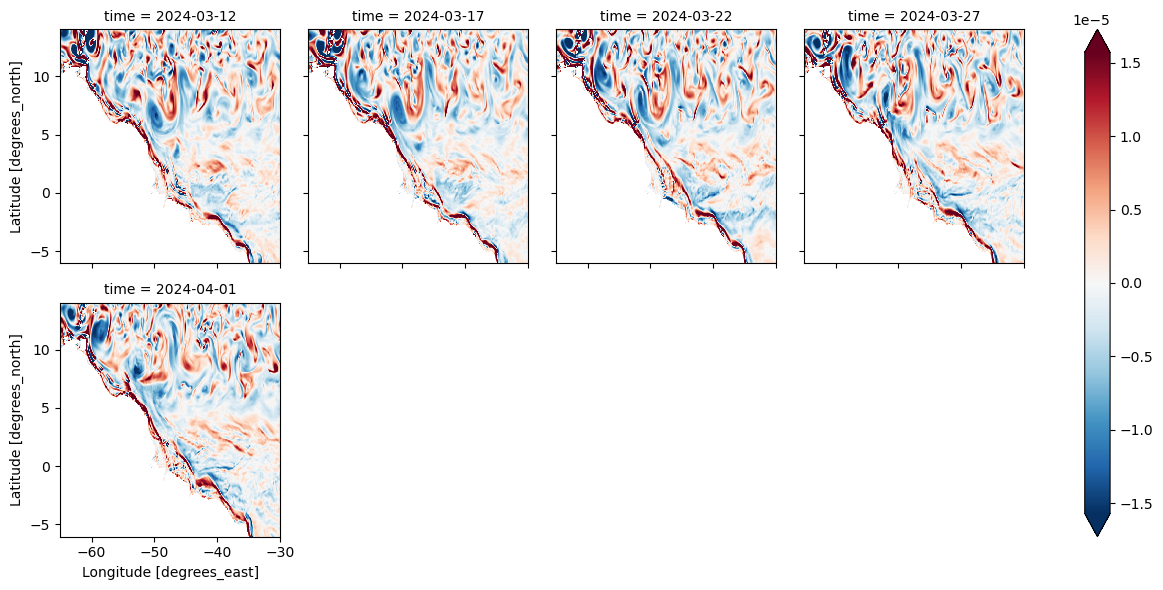

In [63]:
vort5.sel(time=slice('2024-03-10','2024-04-01')).sel(longitude=slice(-65,-30),latitude=slice(-6,14)).plot(col='time',
                                                                                                          col_wrap=4, robust=True,cmap='RdBu_r')

In [68]:
ds_uv = xr.Dataset(
    dict(
        speed=UV5.rename('speed'),
        KE=KE5.rename('KE'),
        vorticity=vort5.rename('vorticity'),
    )
)

ds_uv.speed.attrs = {'units': 'm s-1', 'long_name': '5 day avg resultant water velocity'}
ds_uv.KE.attrs = {'units': 'm2 s-2', 'long_name': '5 day avg kinetic energy per unit mass'}
ds_uv.vorticity.attrs = {'units': 's-1', 'long_name': '5 day avg relative vorticity (dv/dx - du/dy)'}

# ds_uv.to_netcdf('ds_uv5.nc')
    

## Case Study March-April 2024 daily data

In [12]:
sal = sal.sel(time=slice('2024-03-01','2024-04-30')).compute()
optics = optics.sel(time=slice('2024-03-01','2024-04-30')).compute()
ssh = ssh.sel(time=slice('2024-03-01','2024-04-30')).compute()

In [13]:
sal.to_netcdf('sal_cs.nc')
optics.to_netcdf('optics_cs.nc')
ssh.to_netcdf('ssh_cs.nc')

In [15]:
ds_UV = xr.Dataset(
    dict(
        U = U.uo.sel(time=slice('2024-03-01','2024-04-30')),
        V = V.vo.sel(time=slice('2024-03-01','2024-04-30')),
        speed=UV.rename('speed').sel(time=slice('2024-03-01','2024-04-30')),
        KE=KE.rename('KE').sel(time=slice('2024-03-01','2024-04-30')),
        vorticity=vort.rename('vorticity').sel(time=slice('2024-03-01','2024-04-30')),
    )
)

ds_UV.to_netcdf('uv_cs')

## Videos for plume particle description

In [ ]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

# 1) Open dataset (skip if already open)
# ds = xr.open_dataset('path_to_your_file.nc')  # has variable 'so'

da = sal5['so']  # salinity (time, latitude, longitude)
lat = sal5['latitude']; lon = sal5['longitude']

# 2) Choose a time range (optional: keep all)
da = da.sel(time=slice('2024-03-01', '2024-04-25'))

# 3) Output folder
outdir = 'frames'
os.makedirs(outdir, exist_ok=True)

# 4) Consistent color scale (pick robust range once)
vmin = float(da.quantile(0.02).compute())
vmax = float(da.quantile(0.98).compute())

# 5) Render each frame
proj = ccrs.PlateCarree()
extent = [float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())]

for i, t in enumerate(da['time'].values):
    frame = da.sel(time=t)
    fig, ax = plt.subplots(figsize=(8, 4.5), subplot_kw={'projection': proj})
    pm = frame.plot(
        x='longitude', y='latitude',
        ax=ax, transform=proj,
        cmap='viridis_r', vmin=vmin, vmax=vmax,
        add_colorbar=True
    )
    ax.coastlines(resolution='110m', linewidth=0.6)
    ax.add_feature(cf.BORDERS, linewidth=0.3)
    ax.add_feature(cf.LAND, facecolor='#8e9497ff', edgecolor='none')
    ax.set_extent(extent, crs=proj)

    # Title
    ax.set_title(f"Salinity (so), {np.datetime_as_string(t, unit='D')}")
    fig.tight_layout()

    fname = os.path.join(outdir, f"frame_{i:04d}.png")
    plt.savefig(fname, dpi=150)
    plt.close(fig)

print(f"Saved frames to {outdir}/")